### Netflix Content Analysis

#### Data Understanding

This notebook focuses on understanding the structure, quality, and characteristics of the Netflix dataset before any preprocessing or exploratory analysis is performed.

The goal is to identify potential data quality issues, understand feature distributions, inspect data types, and establish a foundation for subsequent preprocessing and EDA.

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")

In [ ]:
# Dataset summary
def dataset_summary(df):
    print("=" * 60)
    print("DATASET SUMMARY")
    print("=" * 60)

    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

    print("\nColumn Names:\n")
    print(df.columns.tolist())

    print("\nData Types:\n")
    print(df.dtypes)

    print("\nMemory Usage:")
    print(f"{df.memory_usage(deep=True).sum()/1024:.2f} KB")

In [ ]:
# Missing values
def missing_values(df):

    missing = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Percentage": (df.isnull().sum()/len(df))*100
    })

    return missing.sort_values("Missing Values", ascending=False)

In [4]:
# Unique values
def unique_values(df):

    return pd.DataFrame({
        "Unique Count": df.nunique(),
        "Data Type": df.dtypes
    }).sort_values("Unique Count", ascending=False)

In [5]:
#Duplicate check
def duplicate_summary(df):

    duplicates = df.duplicated().sum()

    print(f"Duplicate Rows: {duplicates}")

In [3]:
df = pd.read_csv("../data/raw/Netflix Dataset.csv")

In [7]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [8]:
df.shape # Shape of the dataset

(7789, 11)

In [9]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='str')

In [10]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [11]:
df.tail()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7788,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [12]:
# Dataset summary using the helper function defined above
dataset_summary(df)

DATASET SUMMARY
Rows    : 7789
Columns : 11

Column Names:

['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country', 'Release_Date', 'Rating', 'Duration', 'Type', 'Description']

Data Types:

Show_Id         str
Category        str
Title           str
Director        str
Cast            str
Country         str
Release_Date    str
Rating          str
Duration        str
Type            str
Description     str
dtype: object

Memory Usage:
7641.15 KB


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Show_Id       7789 non-null   str  
 1   Category      7789 non-null   str  
 2   Title         7789 non-null   str  
 3   Director      5401 non-null   str  
 4   Cast          7071 non-null   str  
 5   Country       7282 non-null   str  
 6   Release_Date  7779 non-null   str  
 7   Rating        7782 non-null   str  
 8   Duration      7789 non-null   str  
 9   Type          7789 non-null   str  
 10  Description   7789 non-null   str  
dtypes: str(11)
memory usage: 669.5 KB


In [14]:
# Descriptive statistics
df.describe()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s684,Movie,Backfire,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


In [4]:
df.describe(include="object") # Categorical variables

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s684,Movie,Backfire,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


In [16]:
# Missing values analysis using the helper function
missing_values(df)

,Missing Values,Percentage
Director,2388,30.658621
Cast,718,9.218128
Country,507,6.509180
Release_Date,10,0.128386
Rating,7,0.089870
Show_Id,0,0.000000
Category,0,0.000000
Title,0,0.000000
Duration,0,0.000000
Type,0,0.000000


Visualization of the missing value analysis. First plot showing the missing values of each variable and second plot shows the percentage of missing values in each variables

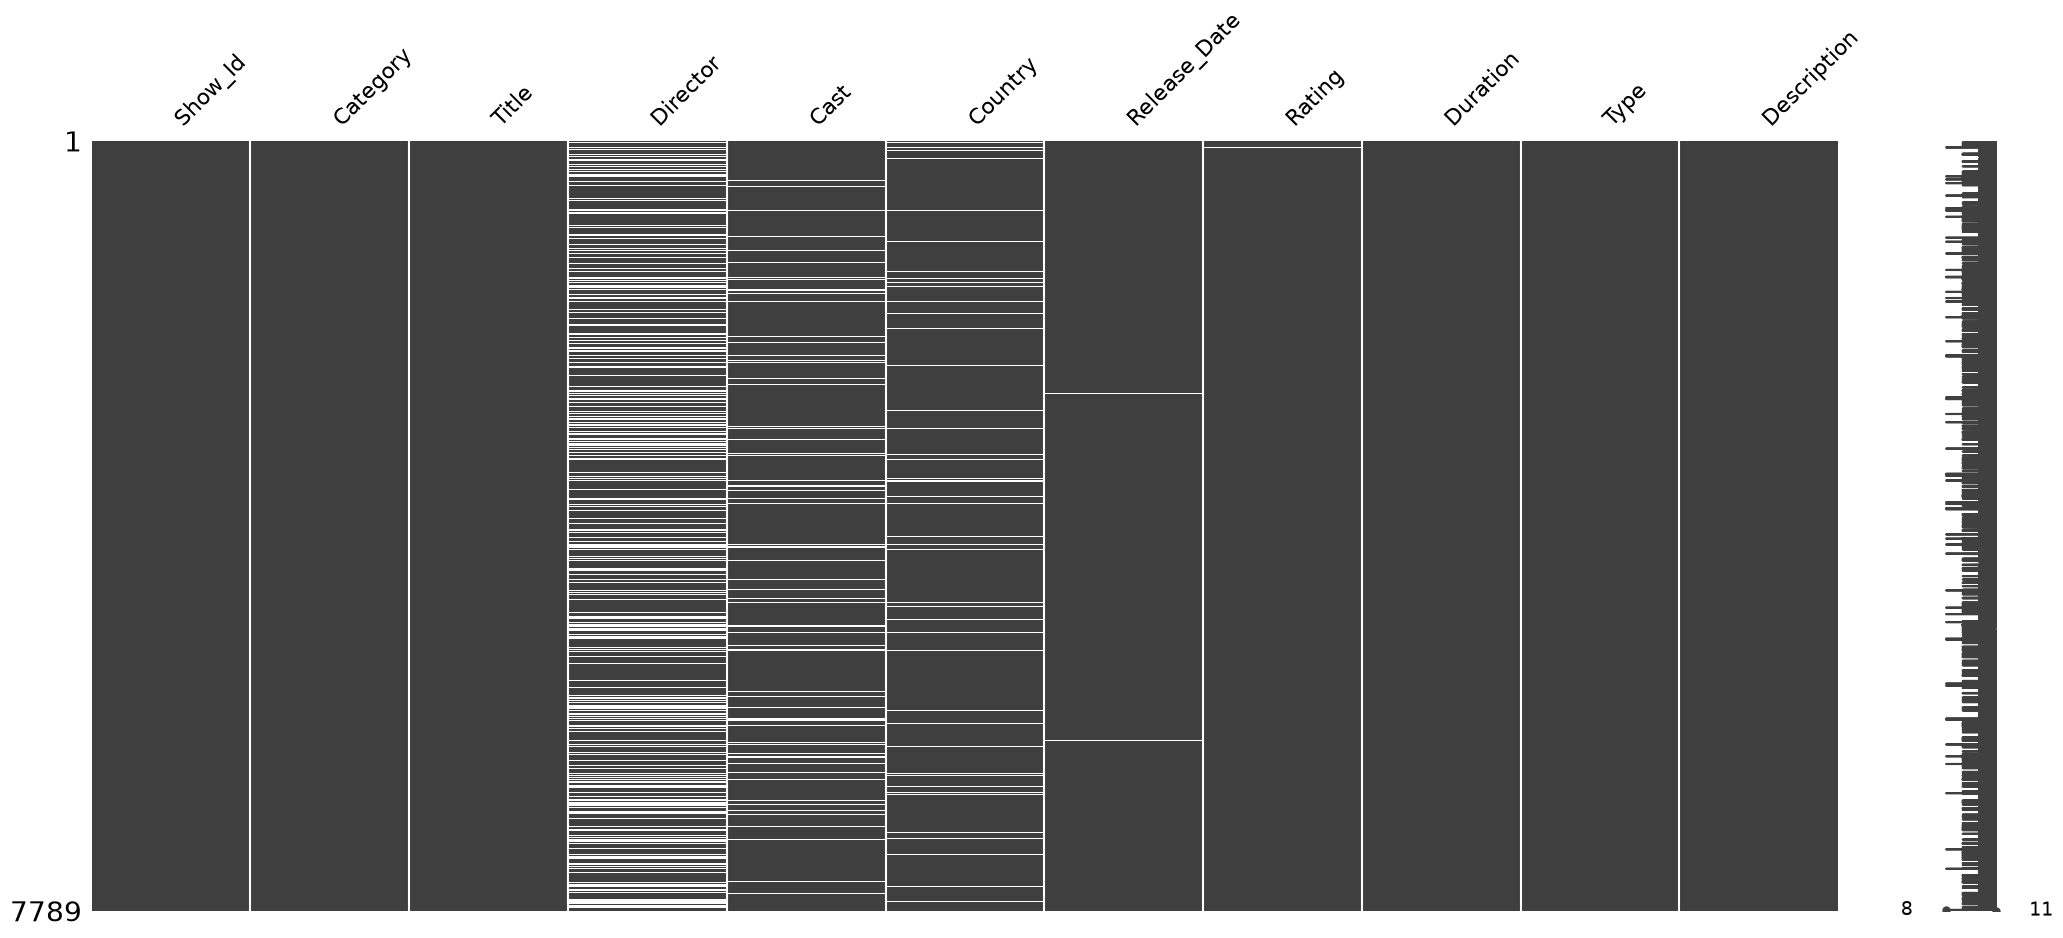

In [17]:
msno.matrix(df)
plt.show()

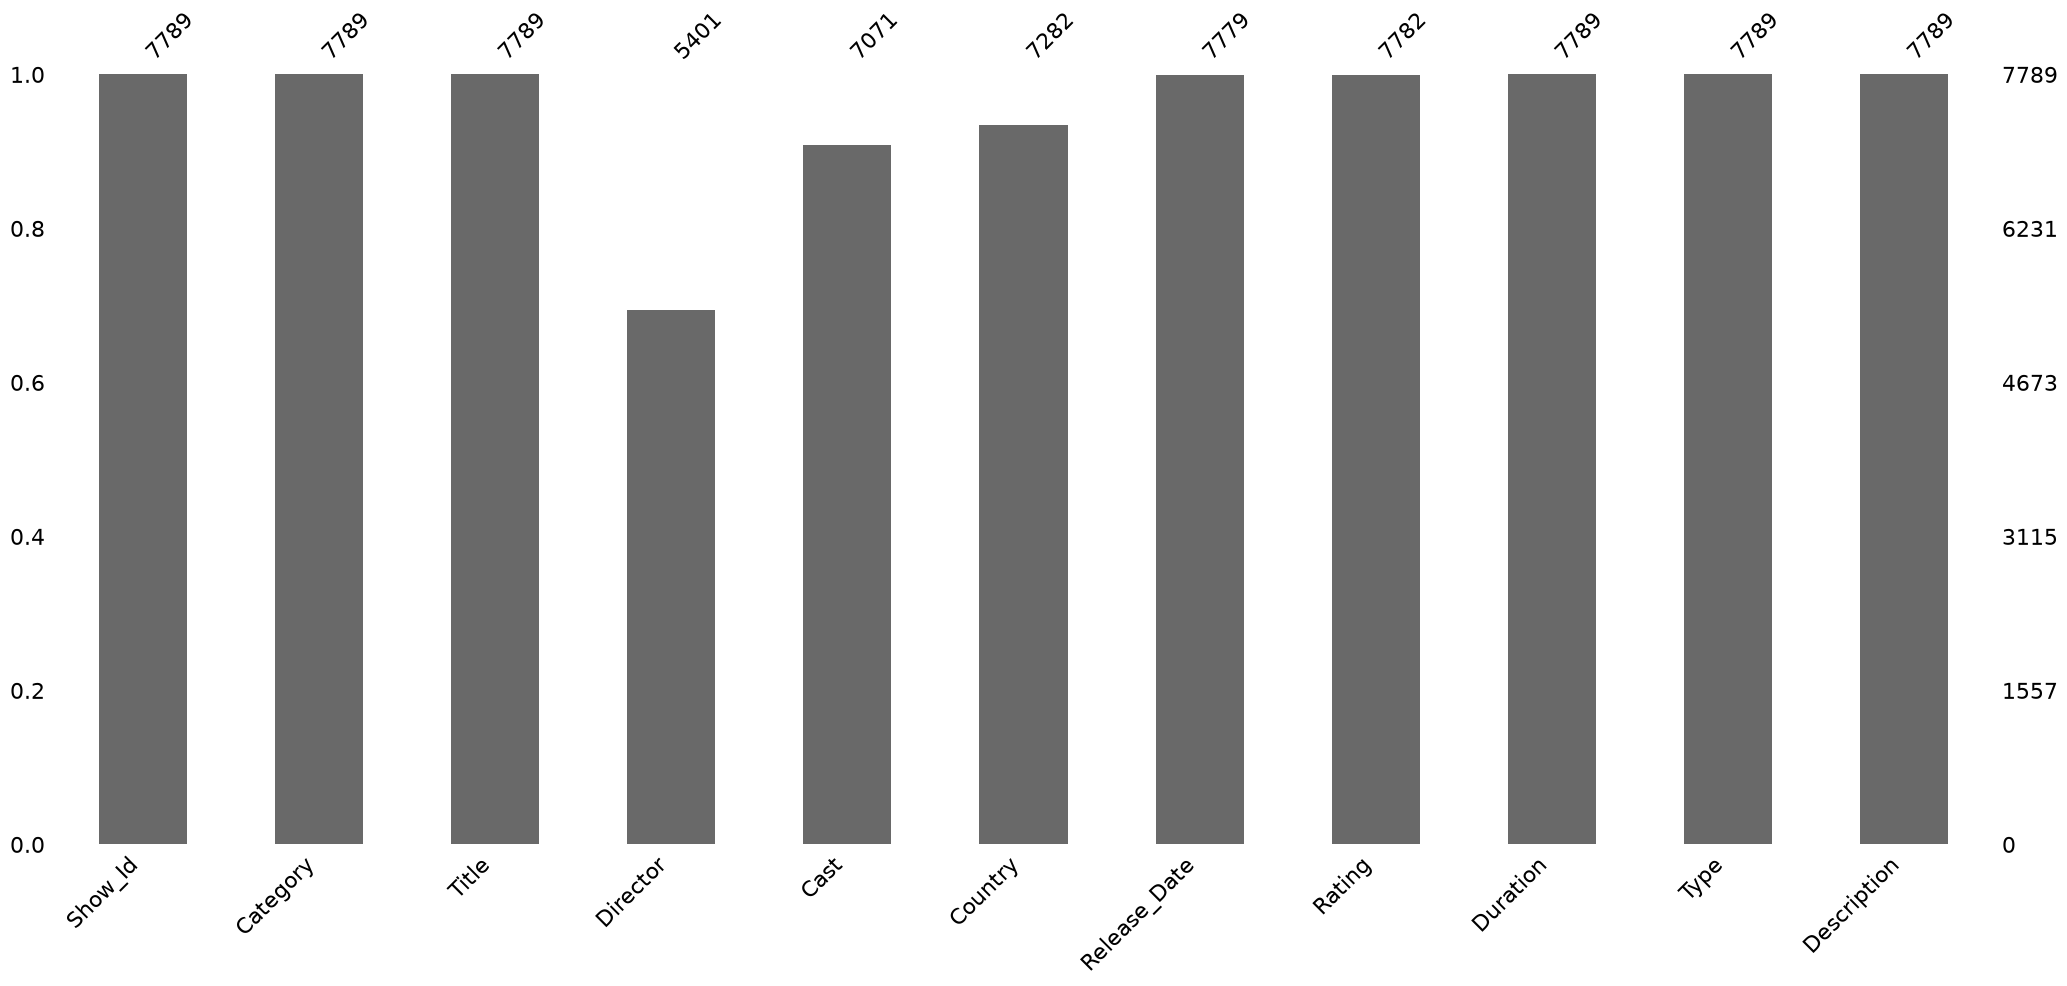

In [18]:
msno.bar(df)
plt.show()

In [19]:
duplicate_summary(df) # Duplicate analysis using helper function

Duplicate Rows: 2


In [20]:
df[df.duplicated()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
6300,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,"April 5, 2019",TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
6622,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,"September 4, 2020",TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


In [21]:
unique_values(df) # Unique value analysis using the helper function

,Unique Count,Data Type
Show_Id,7787,str
Title,7787,str
Description,7769,str
Cast,6831,str
Director,4050,str
Release_Date,1565,str
Country,681,str
Type,492,str
Duration,216,str
Rating,14,str


In [22]:
df["Category"].value_counts()

Category
Movie      5379
TV Show    2410
Name: count, dtype: int64

In [23]:
df["Rating"].value_counts()

Rating
TV-MA       2865
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [24]:
df["Country"].value_counts().head(20)

Country
United States                    2556
India                             923
United Kingdom                    397
Japan                             226
South Korea                       183
Canada                            177
Spain                             134
France                            115
Egypt                             101
Mexico                            100
Turkey                            100
Australia                          83
Taiwan                             78
Brazil                             72
Nigeria                            71
Philippines                        71
Indonesia                          70
United Kingdom, United States      64
Germany                            61
United States, Canada              60
Name: count, dtype: int64

In [25]:
df["Type"].value_counts().head(20)

Type
Documentaries                                        334
Stand-Up Comedy                                      321
Dramas, International Movies                         320
Comedies, Dramas, International Movies               243
Dramas, Independent Movies, International Movies     215
Kids' TV                                             205
Children & Family Movies                             177
Documentaries, International Movies                  172
Children & Family Movies, Comedies                   169
Comedies, International Movies                       161
Dramas, International Movies, Romantic Movies        153
Comedies, International Movies, Romantic Movies      139
Dramas                                               117
Action & Adventure, Dramas, International Movies     117
International TV Shows, TV Dramas                    111
Dramas, International Movies, Thrillers              109
Crime TV Shows, International TV Shows, TV Dramas    106
Comedies, Dramas, Independ

In [26]:
df.memory_usage(deep=True) # Checking the memory usage

Index               132
Show_Id          481810
Category         487738
Title            593394
Director         475502
Cast            1311385
Country          521614
Release_Date     559360
Rating           478428
Duration         498872
Type             703732
Description     1879332
dtype: int64

In [27]:
df.memory_usage(deep=True).sum()/1024

np.float64(7804.0029296875)

##### Initial Observations

- The dataset contains **7,789 records** and **11 features**, providing metadata for Netflix Movies and TV Shows. :contentReference[oaicite:0]{index=0}

- Most columns are stored as **object (string)** data types, indicating that the dataset is predominantly categorical. The `Release_Date` column is currently stored as text and should be converted to a `datetime` data type during preprocessing.

- The dataset contains both **Movies** and **TV Shows**, with the `Category` column distinguishing between the two content types. The `Duration` column stores values in different formats (minutes for movies and seasons for TV shows), which will require standardization before analysis.

- Several metadata columns contain missing values. The **Director** column has the highest proportion of missing data (2,388 records, 30.66%), followed by **Cast** (718 records, 9.22%) and **Country** (507 records, 6.51%). Only a small number of missing values are present in `Release_Date` and `Rating`, while the remaining columns are complete. :contentReference[oaicite:1]{index=1}

- The `Show_Id` column appears to uniquely identify each Netflix title and can serve as the primary identifier for the dataset.

- Columns such as `Cast`, `Country`, and `Type` contain multiple values separated by commas, indicating that they represent one-to-many relationships. These columns may require splitting or feature engineering depending on the analysis objectives.

- Textual fields such as `Title` and `Description` contain high-cardinality information and may be useful for natural language processing or content-based analysis but are not directly suitable for statistical analysis.

- The dataset consists primarily of categorical and textual attributes, suggesting that much of the exploratory analysis will focus on frequency distributions, category comparisons, temporal trends, and content characteristics rather than numerical analysis.

##### Data Understanding Summary

The data understanding phase provided a comprehensive overview of the Netflix content dataset before any preprocessing was performed. The dataset consists of **7,789 Netflix titles** described using **11 metadata attributes**, including content category, title, director, cast, country, release date, maturity rating, duration, genre, and description. :contentReference[oaicite:2]{index=2}

Initial inspection revealed that the dataset is predominantly composed of categorical and textual variables, with no significant numerical features. Several metadata columns contain missing values, particularly `Director`, `Cast`, and `Country`, while the remaining columns are largely complete. :contentReference[oaicite:3]{index=3}

The inspection also identified several characteristics that will influence preprocessing. The `Release_Date` column requires conversion to a datetime format, while the `Duration` column contains mixed units representing either minutes or seasons. Furthermore, columns such as `Cast`, `Country`, and `Type` contain multiple comma-separated values, making them suitable candidates for feature engineering and transformation.

Overall, the dataset appears to be well-structured and suitable for exploratory data analysis after addressing the identified data quality issues. The insights gained during this phase establish a clear roadmap for the subsequent data preprocessing stage, where missing values, data type conversions, and feature transformations will be performed.